# <div align="center"><b> Detección de palmeras mediante YoloV11 </b></div>

<div align="right">

<!-- [![Binder](http://mybinder.org/badge.svg)](https://mybinder.org/) -->
[![nbviewer](https://img.shields.io/badge/render-nbviewer-orange?logo=Jupyter)](https://nbviewer.org)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com)

</div>

* * *

<style>
/* Limitar la altura de las celdas de salida en html */
.jp-OutputArea.jp-Cell-outputArea {
    max-height: 500px;
}
</style>

🛻 <em><font color='MediumSeaGreen'>  Instalaciones: </font></em> 🛻

Este notebook utiliza [Poetry](https://python-poetry.org/) para la gestión de dependencias.
Primero instala Poetry siguiendo las instrucciones de su [documentación oficial](https://python-poetry.org/docs/#installation).
Luego ejecuta el siguiente comando para instalar las dependencias necesarias y activar el entorno virtual:

- Bash:
```bash
poetry install
eval $(poetry env activate)
```

- PowerShell:
```powershell
poetry install
Invoke-Expression (poetry env activate)
```

<!-- Descargar archivos adicionales:
!gdown https://drive.google.com/drive/folders/1UBZ8PEbtmiWMGkULu7GAt3VhUpeTy9l7?usp=sharing --folder -->

In [1]:
# Chequear versión de CUDA
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Oct_30_01:18:48_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.85
Build cuda_12.6.r12.6/compiler.35059454_0


In [2]:
# Chequear más datos sobre la GPU
!nvidia-smi

Sat Sep  6 22:51:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   31C    P8              4W /  320W |     394MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

✋ <em><font color='DodgerBlue'>Importaciones:</font></em> ✋

In [3]:
# Recarga automática de módulos en Jupyter Notebook
%reload_ext autoreload
%autoreload 2

import sys, json, requests, os, shutil, yaml, random
from pathlib import Path
from pprint import pprint

from loguru import logger as LOGGER
from modulo_ia.config import config as CONFIG
from modulo_apps.database_comunication.mongodb_client import mongodb as MONGODB

# os.environ["ALBUMENTATIONS_DISABLE"] = "1" # Deshabilita Albumentations por defecto.
import ultralytics
from ultralytics import YOLO, settings
from ultralytics.data.utils import visualize_image_annotations
import torch

import mlflow
import cv2
import PIL
from PIL import Image
import pandas as pd

import modulo_ia.dataset as DatasetProcessor
import modulo_ia.features as FeaturesProcessor
import modulo_ia.utils.gpu as GpuUtils
import modulo_ia.utils.yolo_utils as YoloUtils
from modulo_ia.modeling.predict import DetectionModelPredictor
from modulo_ia.utils.types import DatasetFormat

import modulo_apps.labeling.procesador_anotaciones_coco_dataset as CocoDatasetUtils
import modulo_apps.s3_comunication.procesador_s3 as ProcesadorS3
import modulo_apps.labeling.visualizador_coco_dataset as VisualizadorCocoDataset
import modulo_apps.labeling.procesador_anotaciones_mongodb as ProcesadorAnotacionesMongoDB
import modulo_apps.labeling.procesador_geojson_kml as ProcesadorGeoJSONKML
from modulo_apps.utils.types import ImageMetadata

2025-09-06 22:51:57.175 | INFO     | modulo_apps.config:<module>:18 - Directorio de configuración raíz: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-apps
2025-09-06 22:51:57.177 | INFO     | modulo_apps.config:<module>:22 - Variables de entorno cargadas desde .env.dev.


2025-09-06 22:51:57.191 | INFO     | modulo_ia.config:<module>:19 - Directorio de configuración raíz: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA
2025-09-06 22:51:57.194 | INFO     | modulo_ia.config:<module>:23 - Variables de entorno cargadas desde .env.dev.


e:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-09-06 22:52:02.123 | DEBUG    | modulo_ia.modeling.predict:<module>:20 - Ambiente actual: dev


🔧 <em><font color='tomato'>Configuraciones:</font></em> 🔧


In [ ]:
# CONFIGURACIONES GENERALES
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # Establece el dispositivo.
LOGGER.remove()
LOGGER.add(sys.stderr, level="INFO")
PIL.Image.MAX_IMAGE_PIXELS = None

# COMPORTAMIENTO DEL NOTEBOOK
SHOULD_PROCESS_DATASET = False  # Descarga el dataset completo
SHOULD_TRAIN = True  # Entrenamiento
SHOULD_SEARCH_HYPERPARAMETERS = False  # Búsqueda de hiperparámetros

# CARPETAS
RAW_DATA_FOLDER = CONFIG.folders.raw_data_folder
EXTERNAL_DATA_FOLDER = CONFIG.folders.external_data_folder
INTERIM_DATA_FOLDER = CONFIG.folders.interim_data_folder
PROCESSED_DATA_FOLDER = CONFIG.folders.processed_data_folder
DATA_FOLDER = CONFIG.folders.data_folder
DOWNLOAD_COCO_ANNOTATIONS_FOLDER = Path("downloads") / "coco_annotations"  # Carpeta para descargar anotaciones COCO
DOWNLOAD_PREDICTION_FOLDER = Path("downloads") / "predictions"  # Carpeta para descargar parches de prueba
MODEL_FOLDER = CONFIG.folders.models_folder

# CONFIGURACIONES DE ENTRENAMIENTO
BATCH_SIZE = 16  # 16 -> Yolo11x | # 64 -> Yolo11n
N_EPOCHS = 350  # Número de épocas
VERBOSE = True  # Muestra época a época la evolución
IMG_SIZE = 640  # Tamaño de la imagen
RANDOM_SEED = CONFIG.seed  # Semilla para la aleatoriedad
CROP_THRESHOLD = 0.4  # Umbral de recorte para el dataset
BACKGROUND_PERCENTAGE = 0.1  # Porcentaje de fondo en el dataset balanceado
FREEZE_LAYERS = 10  # Número de capas a congelar
EARLY_STOPPING = 10  # Paciencia para el early stopping

# DATA AUGMENTATIONS
# Opciones: train_no_aumentations.yaml | train_custom1_aumentations.yaml | train_custom2_aumentations.yaml
AUMENTATIONS_CONFIG_FILE_PATH = Path("train_custom2_aumentations.yaml")
CUSTOM_TRANSFORMS = [str(AUMENTATIONS_CONFIG_FILE_PATH).replace(".yaml", "")]

# TAREA
TASK_NAME = "palm_detection"
CLASS_NAMES = {0: "palmera"}
COLOR_MAP = {
    "palmera": (0, 255, 0),  # Verde
}
CATEGORIES = [{"id": id, "name": name, "supercategory": ""} for id, name in CLASS_NAMES.items()]

# MODELO
MODEL_NAME = "yolo11x"
# Opciones: f"{MODEL_NAME}.pt" | Ruta al checkpoint personalizado
MODEL_CHECKPOINT = f"{MODEL_NAME}.pt"

# DATOS DEL DATASET
DATASET_NAME = CONFIG.names.palm_dataset_name
DATASET_VERSION = CONFIG.versions.v11
DATASET_IDENTIFIER = f"{DATASET_NAME}_{DATASET_VERSION}"
DATASET_FINAL_FORMAT = CONFIG.datasets_processed_format.yolo  # Formato final del dataset procesado

# RUTAS Y NOMBRES
DATASET_RAW_NAME = DATASET_IDENTIFIER
DATASET_RAW_PATH = RAW_DATA_FOLDER / DATASET_RAW_NAME
DATASET_INTERIM_NAME = DATASET_IDENTIFIER
DATASET_INTERIM_PATH = INTERIM_DATA_FOLDER / DATASET_INTERIM_NAME
DATASET_INTERIM_STEP_PATH = INTERIM_DATA_FOLDER / f"{DATASET_INTERIM_NAME}_step"
DATASET_INTERIM_STEP_NAME = f"{DATASET_INTERIM_NAME}_step"
DATASET_PROCESSED_NAME = f"{DATASET_IDENTIFIER}_{TASK_NAME}_{DATASET_FINAL_FORMAT}"
DATASET_PROCESSED_PATH = PROCESSED_DATA_FOLDER / DATASET_PROCESSED_NAME
EXPERIMENT_NAME = f"{DATASET_IDENTIFIER}_{TASK_NAME}_{MODEL_NAME.replace('/', '_')}_{IMG_SIZE}"

# MLFLOW
MLFLOW_URL = CONFIG.mlflow.tracking_uri
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_URL  # Configura la URI de seguimiento de MLflow.
os.environ["MLFLOW_TAGS"] = '{"model_family": "rpw_detection"}'  # Configura las etiquetas del experimento de MLflow.
settings.update({"mlflow": True})  # Habilita el uso de MLflow en ultralytics

# COMPROBACIONES
ultralytics.checks()  # Verifica la instalación de ultralytics
LOGGER.info(f"Dispositivo actual: {DEVICE}")

Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
Setup complete  (20 CPUs, 127.9 GB RAM, 854.3/1862.9 GB disk)


2025-09-06 22:52:02.389 | INFO     | __main__:<module>:73 - Dispositivo actual: cuda


<div align="center">✨Datos del proyecto:✨</div>

<p></p>

<div align="center">

| **Subtitulo**   | Detección de palmeras - YoloV11                                                                                                        |
| --------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **Descrpción**  | <small>Notebook de detección de palmeras utilizando YoloV11</small>                                                                    |

</div>

## Chequeo de conexiones

In [5]:
# Chequeo de conexión a MLflow
LOGGER.info(f"Conectando a MLflow en {MLFLOW_URL}...")
try:
    response = requests.get(MLFLOW_URL)
    response.raise_for_status()  # Verifica si la solicitud fue exitosa.
    LOGGER.success("Conexión a MLflow establecida correctamente.")
    
except Exception as e:
    LOGGER.error(f"Error al conectar con MLflow. Tienes levantado el servidor de MLflow?")
    raise SystemExit(f"Error al conectar con MLflow: {e}")

if SHOULD_PROCESS_DATASET:
    # Chequeo de conexión a MinIO
    LOGGER.info("Chequeando conexión a MinIO...")
    ProcesadorS3.test_connection()

# Chequeo de conexión a MongoDB
LOGGER.info("Chequeando conexión a MongoDB...")
ProcesadorAnotacionesMongoDB.test_connection()
LOGGER.success("Conexión a MongoDB verificada correctamente.")

2025-09-06 22:52:02.447 | INFO     | __main__:<module>:2 - Conectando a MLflow en http://localhost:5000...
2025-09-06 22:52:02.454 | SUCCESS  | __main__:<module>:6 - Conexión a MLflow establecida correctamente.
2025-09-06 22:52:02.455 | INFO     | __main__:<module>:18 - Chequeando conexión a MongoDB...
2025-09-06 22:52:02.464 | SUCCESS  | modulo_apps.labeling.procesador_anotaciones_mongodb:test_connection:38 - Conexión a la base de datos MongoDB exitosa.
2025-09-06 22:52:02.465 | SUCCESS  | __main__:<module>:20 - Conexión a MongoDB verificada correctamente.


## Raw dataset

In [6]:
if DATASET_RAW_PATH.exists():
    LOGGER.info("Dataset ya descargado. Procesando dataset...")

    dataset_metrics = DatasetProcessor.get_dataset_metrics(
        dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=DatasetProcessor.DatasetFormat.COCO
    )
    dataset_stats = DatasetProcessor.get_dataset_stats(
        dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=DatasetProcessor.DatasetFormat.COCO
    )
    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")
    LOGGER.info(f"Estadísticas del dataset:\n {json.dumps(dataset_stats, indent=2)}")
else:
    LOGGER.error(f"El dataset no fue encontrado en {DATASET_RAW_PATH}. Tienes que descargarlo previamente.")
    sys.exit(1)

2025-09-06 22:52:02.519 | INFO     | __main__:<module>:2 - Dataset ya descargado. Procesando dataset...


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
 100% |█████████████████| 892/892 [3.6s elapsed, 0s remaining, 219.6 samples/s]      
 100% |█████████████████| 892/892 [3.5s elapsed, 0s remaining, 201.9 samples/s]      


2025-09-06 22:52:09.831 | INFO     | __main__:<module>:10 - Metricas del dataset:
 {
  "total_images_count": 892,
  "total_images_with_detections": 892,
  "total_images_without_detections": 0,
  "class_count": {
    "palmera-infectada": 57,
    "palmera-exterminada": 40,
    "palmera-sana": 5670,
    "palmera-muerta": 110
  }
}
2025-09-06 22:52:09.832 | INFO     | __main__:<module>:11 - Estadísticas del dataset:
 {
  "samples_count": 892,
  "samples_bytes": 1699837,
  "samples_size": "1.6MB",
  "media_bytes": 0,
  "media_size": "0.0B",
  "total_bytes": 1699837,
  "total_size": "1.6MB"
}


## Procesamiento del dataset

### Convertir todas las clases a una sola

In [7]:
CUSTOM_TRANSFORMS.append("delete_label: palmera-exterminada")  # Agrega la transformación de eliminación de etiqueta
CUSTOM_TRANSFORMS.append("assign_to_single_label: palmera")  # Agrega la transformación de asignación de etiqueta
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Cambiando la etiqueta del dataset a 'palmera'...")
    # Copiamos el dataset a la carpeta de datos
    shutil.copytree(DATASET_RAW_PATH, DATASET_INTERIM_PATH, dirs_exist_ok=True)
    
    json_folder = DATASET_INTERIM_PATH
    coco_anotations = CocoDatasetUtils.load_annotations_from_path(json_folder / "labels.json")

    LOGGER.info("Eliminando etiqueta 'palmera-exterminada'...")    
    coco_anotations = CocoDatasetUtils.delete_label(coco_anotations, "palmera-exterminada")
    

    LOGGER.info("Asignando la etiqueta 'palmera' a todas las anotaciones...")
    coco_annotations_one_class = CocoDatasetUtils.assign_to_single_label(coco_anotations, CLASS_NAMES[0])
    

    with open(json_folder / "labels.json", "w") as f:
        json.dump(coco_annotations_one_class, f, indent=4)
        LOGGER.info(f"Se copió el dataset y se guardó el archivo de etiquetas en {json_folder / 'labels.json'}")

    LOGGER.info(f"Nuevas categorías:\n {json.dumps(coco_anotations['categories'], indent=2)}")

### Convertir dataset a formato YOLO
<small><em>https://docs.ultralytics.com/reference/cfg/__init__/</em></small>

In [8]:
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Convirtiendo el dataset a formato de modelo...")
    DatasetProcessor.convert_dataset_to_model_format(dataset_path=DATASET_INTERIM_PATH, output_dir=DATASET_INTERIM_STEP_PATH, clean=True)

Ejemplo con views splits:

```python
for split in splits:
    split_view = dataset_or_view.match_tags(split)
    split_view.export(
        export_dir=export_dir,
        dataset_type=fo.types.YOLOv5Dataset,
        label_field=label_field,
        split=split,
        classes=classes,
    )
```

### Recortar el dataset en imágenes pequeñas

In [9]:
CUSTOM_TRANSFORMS.append(f"crop: {CROP_THRESHOLD}")  # Agrega la transformación de recorte
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Cortando el dataset para entrenamiento...")
    FeaturesProcessor.crop_dataset(dataset_path=DATASET_INTERIM_STEP_PATH, image_size=IMG_SIZE, threshold=CROP_THRESHOLD)

    dataset_metrics = DatasetProcessor.get_dataset_metrics(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        dataset_name=DATASET_INTERIM_STEP_NAME,
        dataset_format=DatasetFormat.YOLO,
    )

    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")

### Balancear el dataset

In [10]:
CUSTOM_TRANSFORMS.append(f"balance: {BACKGROUND_PERCENTAGE}")  # Agrega la transformación de balanceo
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Balanceando el dataset...")
    FeaturesProcessor.balance_dataset_v1(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        output_path=DATASET_INTERIM_STEP_PATH,
        all_classes=False,
        background_precentage=BACKGROUND_PERCENTAGE,
        export_categories=CATEGORIES,
    )
    
    dataset_metrics = DatasetProcessor.get_dataset_metrics(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        dataset_name=DATASET_INTERIM_STEP_NAME,
        dataset_format=DatasetFormat.YOLO,
    )
    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")

### Split del dataset

In [11]:
CUSTOM_TRANSFORMS.append("split: 0.8, 0.1, 0.1")  # Agrega la transformación de split
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Split del dataset...")
    DatasetProcessor.split_dataset(dataset_path=DATASET_INTERIM_STEP_PATH, output_dir=DATASET_PROCESSED_PATH, clean=True, ratios=(0.8, 0.1, 0.1))

### Validaciones del dataset

#### Existencia del archivo dataset.yaml

In [12]:
dataset_yaml_path = DATASET_PROCESSED_PATH / "dataset.yaml"
if not dataset_yaml_path.exists():
    raise FileNotFoundError(f"El archivo {dataset_yaml_path} no existe. Asegúrate de que el dataset se haya procesado correctamente.")
LOGGER.success(f"Archivo dataset.yaml encontrado en {dataset_yaml_path}")

2025-09-06 22:52:10.124 | SUCCESS  | __main__:<module>:4 - Archivo dataset.yaml encontrado en E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.0_palm_detection_yolo\dataset.yaml


#### Congruencia de las clases

In [13]:
with open(dataset_yaml_path, "r") as f:
    dataset_yaml = yaml.safe_load(f)
    LOGGER.debug(f"Dataset YAML cargado: {dataset_yaml}")

DATASET_YAML_CLASS_NAMES = dataset_yaml["names"]
if set(DATASET_YAML_CLASS_NAMES.values()) != set(CLASS_NAMES.values()):
    raise ValueError(f"Las clases del dataset YAML {DATASET_YAML_CLASS_NAMES} no coinciden con las esperadas {CLASS_NAMES.values()}.")

LOGGER.success("Validaciones de clases realizadas correctamente.")

2025-09-06 22:52:10.185 | SUCCESS  | __main__:<module>:9 - Validaciones de clases realizadas correctamente.


### Metricas del dataset procesado

In [14]:
dataset_metrics = DatasetProcessor.get_dataset_metrics(
    dataset_path=DATASET_PROCESSED_PATH,
    dataset_name=DATASET_PROCESSED_NAME,
    dataset_format=DatasetProcessor.DatasetFormat.YOLO,
)
dataset_metrics_json = json.dumps(dataset_metrics, indent=2)
LOGGER.info(f"Metricas del dataset:\n {dataset_metrics_json}")

 100% |███████████████| 5975/5975 [31.3s elapsed, 0s remaining, 212.9 samples/s]      
 100% |█████████████████| 747/747 [3.4s elapsed, 0s remaining, 223.4 samples/s]      
 100% |█████████████████| 747/747 [4.6s elapsed, 0s remaining, 211.0 samples/s]       


2025-09-06 22:52:49.784 | WARNING  | modulo_ia.dataset:get_dataset_metrics:442 - Advertencia: no se pudo agregar el split "full" al dataset. Error: Dataset YAML 'E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.0_palm_detection_yolo\dataset.yaml' does not contain split 'full'
2025-09-06 22:52:49.886 | INFO     | __main__:<module>:7 - Metricas del dataset:
 {
  "train_count": 5975,
  "train_images_with_detections": 5410,
  "train_images_without_detections": 565,
  "train_class_count": {
    "palmera": 9848
  },
  "val_count": 747,
  "val_images_with_detections": 685,
  "val_images_without_detections": 62,
  "val_class_count": {
    "palmera": 1270
  },
  "test_count": 747,
  "test_images_with_detections": 695,
  "test_images_without_detections": 52,
  "test_class_count": {
    "palmera": 1177
  },
  "total_count": 7469,
  "total_images_with_detections": 6790,
  "total_images_without_detections": 679,
  "total_class_coun

### Visualización

#### Observamos el dataset

> 📝 <em><font color='Gray'>Nota:</font></em> Si hay problema de versiones con `FiftyOne`, borrar la base de datos del mismo que se encuentra en: `C:\Users\<usuario>\.fiftyone\`</em>

In [15]:
if SHOULD_PROCESS_DATASET:
    DatasetProcessor.copy_dataset_to_quality(DATASET_PROCESSED_PATH, DATASET_PROCESSED_NAME)

Accedemos a la visualización: <a>http://picudo-rojo-desarrollo.org:5151</a>

#### Observamos algunas imágenes

2025-09-06 22:52:49.989 | INFO     | __main__:<module>:10 - Archivo de texto seleccionado para visualización: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.0_palm_detection_yolo\labels\train\barrioCanadaVictoria_20180801_dji_pc_3cm_patch_52_crop_24.txt


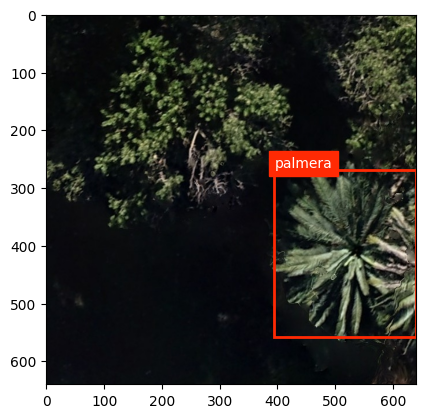

In [16]:
train_image_folder = DATASET_PROCESSED_PATH / "images" / "train"
train_annotations_folder = DATASET_PROCESSED_PATH / "labels" / "train"
# Select one random image from the train folder
if not train_image_folder.exists() or not train_annotations_folder.exists():
    raise FileNotFoundError(f"Las carpetas de entrenamiento no existen: {train_image_folder} o {train_annotations_folder}. Asegúrate de que el dataset se haya procesado correctamente.")
text_files = list(train_annotations_folder.glob("*.txt"))
if not text_files:
    raise FileNotFoundError(f"No se encontraron archivos de texto en {train_annotations_folder}. Asegúrate de que el dataset se haya procesado correctamente.")
text_path = random.choice(text_files)
LOGGER.info(f"Archivo de texto seleccionado para visualización: {text_path}")

image_path = train_image_folder / text_path.with_suffix(".jpg").name
if not image_path.exists():
    raise FileNotFoundError(f"La imagen {image_path} no existe. Asegúrate de que el dataset se haya procesado correctamente.")

category_map = {cat["id"]: cat["name"] for cat in CATEGORIES}

visualize_image_annotations(image_path, text_path, category_map)

#### Observamos el aumento de datos

train: Fast image access  (ping: 0.00.0 ms, read: 48.116.2 MB/s, size: 204.4 KB)


train: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.0_palm_detection_yolo\labels\train.cache... 5975 images, 565 backgrounds, 0 corrupt: 100%|██████████| 5975/5975 [00:00<?, ?it/s]


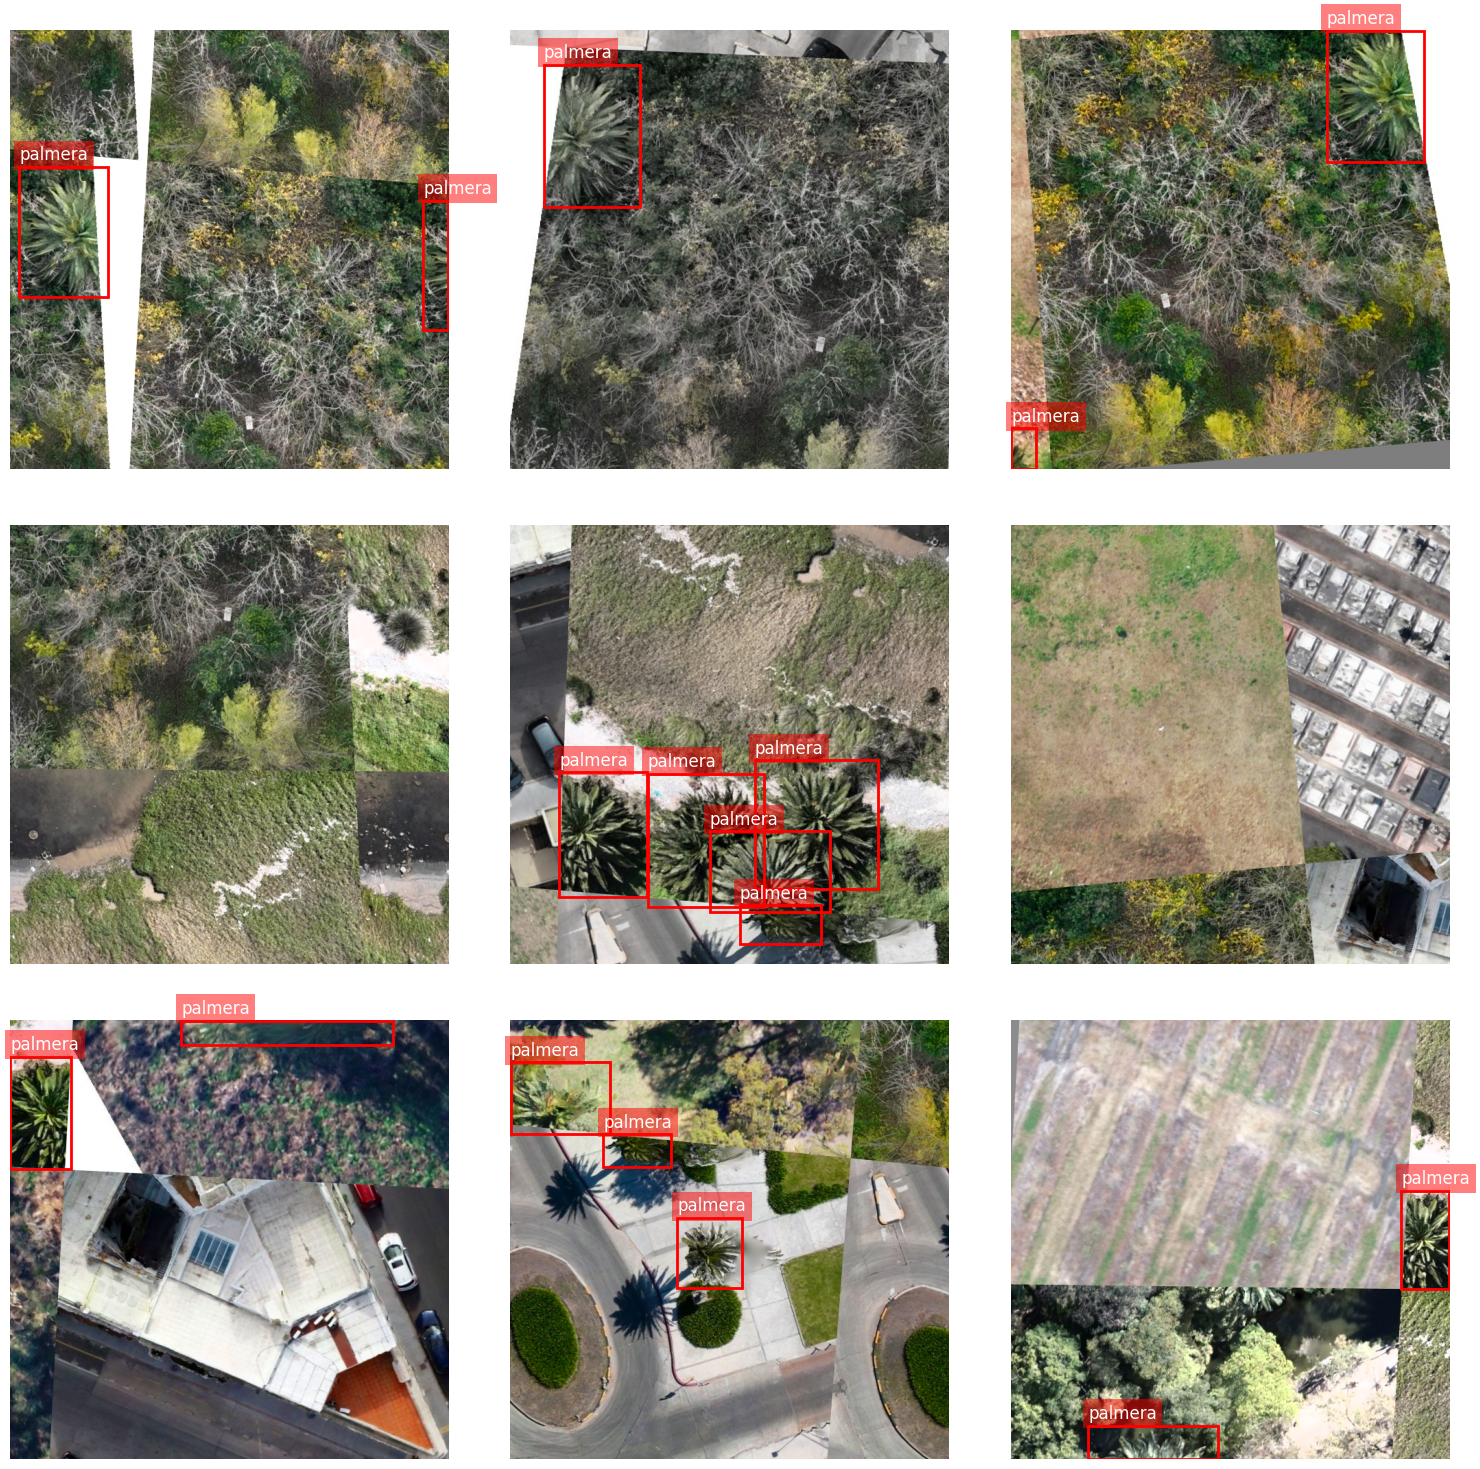

In [17]:
yolo_training_dataloader = YoloUtils.get_yolo_training_dataloader(
    cfg_path=AUMENTATIONS_CONFIG_FILE_PATH,
    cfg_data=DATASET_PROCESSED_PATH / "dataset.yaml",
    cfg_imgsz=IMG_SIZE,
    cfg_batch=9,
    dataset_path=DATASET_PROCESSED_PATH / "images" / "train",
)
YoloUtils.plot_yolo_augmentations(yolo_training_dataloader, CLASS_NAMES, max_batches=1)

## Entrenamiento del modelo

Creamos el modelo de detección de objetos YOLOv11:

<small><em>https://docs.ultralytics.com/modes/train/#train-settings</em></small>

In [18]:
model = YOLO(MODEL_CHECKPOINT)

Imprimimos el modelo:

In [19]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

Mostramos información del modelo:

> 📝 <em><font color='Gray'>Nota:</font></em> $\text{Max batch size} = \frac{\text{Available GPU memory (bytes)}}{4 \times (\text{Size of tensors} + \text{Trainable parameters})}$


In [20]:
print(f"Información básica del modelo:")
model.info()

Información básica del modelo:
YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

Entrenamos el modelo:

- <small>https://docs.ultralytics.com/yolov5/tutorials/tips_for_best_training_results/#advanced-optimization-techniques</small>
- <small>https://docs.ultralytics.com/guides/yolo-data-augmentation/#introduction</small>

In [ ]:
if SHOULD_TRAIN:
    experiment = mlflow.set_experiment(EXPERIMENT_NAME)
    with mlflow.start_run(experiment_id=experiment.experiment_id):
        mlflow.log_param("dataset_name", DATASET_NAME)  # Registra el nombre del dataset
        mlflow.log_param("dataset_version", DATASET_VERSION)  # Registra la versión del dataset
        mlflow.log_param("dataset_format", DATASET_FINAL_FORMAT)  # Registra el formato del dataset
        mlflow.log_param("dataset_processed_name", DATASET_PROCESSED_NAME)  # Registra el nombre del dataset procesado
        mlflow.log_param("dataset_metrics", dataset_metrics_json)  # Registra las métricas del dataset como JSON
        mlflow.log_param(
            "transforms", ", ".join(CUSTOM_TRANSFORMS)
        )  # Registra las transformaciones aplicadas al dataset
        mlflow.log_param("model_name", MODEL_NAME)  # Registra el nombre del modelo
        mlflow.log_param("model_checkpoint", MODEL_CHECKPOINT)  # Registra el checkpoint del modelo
        mlflow.log_param("img_size", IMG_SIZE)  # Registra el tamaño de la imagen
        mlflow.log_param("crop_threshold", CROP_THRESHOLD)  # Registra el umbral de recorte
        mlflow.log_param("background_percentage", BACKGROUND_PERCENTAGE) # Registra el porcentaje de fondo en el dataset balanceado

        history = model.train(
            cfg=str(AUMENTATIONS_CONFIG_FILE_PATH),  # Configuración de aumentaciones
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            epochs=N_EPOCHS,
            batch=BATCH_SIZE,
            device=0,  # Usa la GPU 0
            verbose=VERBOSE,  # Muestra época a época la evolución
            imgsz=IMG_SIZE,
            project=EXPERIMENT_NAME,
            exist_ok=True,
            save_period=10,
            patience=10,
            plots=True,
            # cache=True, # Cachea las imágenes en memoria para acelerar el entrenamiento
            # Parámetros de configuración del entrenamiento
            # optimizer="SGD", # Valores posibles: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
            # cos_lr=True, # Usa decaimiento cosenoidal del learning rate
            # lr0=0.1, # Learning rate inicial. Default=0.01
            # lrf=0.01, # Tasa de aprendizaje final como una fracción de la tasa inicial = (lr0 * lrf). Valor alto=menos decaimiento. Default=0.01, 1% del lr0.
            # momentum=0.937, # Factor de momento para SGD o beta1 para optimizadores Adam
            # weight_decay=0.0005 # Peso de decaimiento (L2 regularization)
            # warmup_epochs=3.0, # Número de épocas para el calentamiento de la tasa de aprendizaje (aumenta gradualmente el lr hasta lr0). Defecto: 3.0
            # warmup_momentum=0.8, # Momentum inicial del calentamiento
            # warmup_bias_lr=0.1, # Tasa de aprendizaje para los parámetros de sesgo durante la fase de calentamiento (ayuda a estabilizar el entrenamiento al inicio)
            # dropout=0.0, # Tasa de dropout
        )

New https://pypi.org/project/ultralytics/8.3.195 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=train_custom1_aumentations.yaml, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.0_palm_detection_yolo\dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=350, erasing=0.1, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_r

train: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.0_palm_detection_yolo\labels\train.cache... 5975 images, 565 backgrounds, 0 corrupt: 100%|██████████| 5975/5975 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 22.15.7 MB/s, size: 165.6 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.0_palm_detection_yolo\labels\val.cache... 747 images, 62 backgrounds, 0 corrupt: 100%|██████████| 747/747 [00:00<?, ?it/s]


Plotting labels to coco_palm_dataset_v1.0_palm_detection_yolo11n_640\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)


...

    327/350      8.32G     0.6335     0.4197      1.012         59        640: 100%|██████████| 94/94 [00:20<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.70it/s]

                   all        747       1270      0.951      0.929       0.97      0.813
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 317, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



327 epochs completed in 2.152 hours.
Optimizer stripped from coco_palm_dataset_v1.0_palm_detection_yolo11n_640\train\weights\last.pt, 5.5MB
Optimizer stripped from coco_palm_dataset_v1.0_palm_detection_yolo11n_640\train\weights\best.pt, 5.5MB

Validating coco_palm_dataset_v1.0_palm_detection_yolo11n_640\train\weights\best.pt...
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:03<00:00,  1.96it/s]


                   all        747       1270       0.95      0.929       0.97      0.814
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to coco_palm_dataset_v1.0_palm_detection_yolo11n_640\train
🏃 View run bedecked-bug-988 at: http://localhost:5000/#/experiments/2/runs/d683c94c38e948c5867fb4eec4438203
🧪 View experiment at: http://localhost:5000/#/experiments/2
MLflow: results logged to http://localhost:5000
MLflow: disable with 'yolo settings mlflow=False'


### Métricas de entrenamiento

In [22]:
try:
    results_df = pd.read_csv(history.save_dir / "results.csv").set_index("epoch")
    results_df["time_diff"] = results_df["time"].diff().fillna(0)
except FileNotFoundError:
    LOGGER.warning("No se encontró el archivo results.csv. Asegúrate de que el entrenamiento se completó correctamente.")
    results_df = pd.DataFrame()
except NameError:
    LOGGER.error("El entrenamiento no se realizó correctamente. Verifica los parámetros de entrenamiento.")
    results_df = pd.DataFrame()
except Exception as e:
    LOGGER.error(f"Error al cargar los resultados del entrenamiento: {e}")
    results_df = pd.DataFrame()
results_df

,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,time_diff
epoch,,,,,,,,,,,,,,,
1,27.2180,1.49485,2.70951,1.54276,0.82243,0.64551,0.73774,0.42439,1.46458,2.30473,1.28896,0.003298,0.003298,0.003298,0.0000
2,52.6553,1.31334,1.51607,1.30051,0.70331,0.57117,0.62978,0.34470,1.54287,1.60093,1.33674,0.006612,0.006612,0.006612,25.4373
3,76.3681,1.36852,1.33539,1.36110,0.41979,0.55827,0.38227,0.20128,1.61733,2.68995,1.59555,0.009908,0.009908,0.009908,23.7128
4,99.6029,1.41515,1.27715,1.42393,0.79374,0.60906,0.68955,0.39918,1.58457,1.75415,1.53700,0.009915,0.009915,0.009915,23.2348
5,122.5440,1.37767,1.20161,1.41949,0.82786,0.61724,0.67448,0.40056,1.63743,1.62163,1.60844,0.009887,0.009887,0.009887,22.9411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,7650.7800,0.62268,0.40985,1.00139,0.95010,0.92913,0.96984,0.81314,0.72653,0.37771,1.02939,0.000892,0.000892,0.000892,23.8700
324,7674.5200,0.61781,0.40440,0.99932,0.95077,0.92992,0.96992,0.81338,0.72642,0.37741,1.02915,0.000864,0.000864,0.000864,23.7400
325,7698.5400,0.63961,0.42328,1.01542,0.95079,0.92992,0.96992,0.81340,0.72614,0.37733,1.02882,0.000835,0.000835,0.000835,24.0200


## Validación del modelo

Cargamos el mejor modelo:

In [23]:
print(f"Nombre del proyecto: {EXPERIMENT_NAME}")
best_model_path = Path(EXPERIMENT_NAME) / "train" / "weights" / "best.pt"

if not best_model_path.exists():
    LOGGER.error(f"El modelo {best_model_path} no existe")
    sys.exit(1)
best_model = YOLO(best_model_path)

Nombre del proyecto: coco_palm_dataset_v1.0_palm_detection_yolo11n_640


Limpiamos la GPU:

In [24]:
GpuUtils.clean_gpu_usage()

Initial GPU Usage
| ID | GPU | MEM |
------------------
|  0 |  0% |  8% |
GPU Usage after emptying the cache
| ID | GPU | MEM |
------------------
|  0 |  0% |  5% |


Validamos el modelo:

In [25]:
metrics = best_model.val(
    project=EXPERIMENT_NAME,
    data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
    split="test",
    exist_ok=True
)

Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 38.110.6 MB/s, size: 164.1 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.0_palm_detection_yolo\labels\test.cache... 747 images, 52 backgrounds, 0 corrupt: 100%|██████████| 747/747 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 47/47 [00:03<00:00, 13.46it/s]


                   all        747       1177      0.959      0.937      0.977       0.83
Speed: 0.2ms preprocess, 1.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to coco_palm_dataset_v1.0_palm_detection_yolo11n_640\val


Imprimimos el reporte de validación:

In [26]:
metrics.summary()

[{'Class': 'palmera',
  'Images': np.int64(695),
  'Instances': np.int64(1177),
  'Box-P': np.float64(0.95913),
  'Box-R': np.float64(0.93704),
  'Box-F1': np.float64(0.94795),
  'mAP50': np.float64(0.97698),
  'mAP50-95': np.float64(0.82984)}]

## Predicción

Cargamos el modelo:

In [27]:
print(f"Nombre del proyecto: {EXPERIMENT_NAME}")
best_model_path = Path(EXPERIMENT_NAME) / "train" / "weights" / "best.pt"
# best_model_path = MODEL_FOLDER / "coco_palm_dataset_v1.0_palm_detection_yolo11n_640_1705a3dd294c499e8cfd8db7415a20c0.pt"

if not best_model_path.exists():
    LOGGER.error(f"El modelo {best_model_path} no existe")
    sys.exit(1)

best_model = YOLO(best_model_path)

Nombre del proyecto: coco_palm_dataset_v1.0_palm_detection_yolo11n_640


Descargamos la imagen de prueba:

In [28]:
# image_name = "barrioCanadaVictoria_20180801_dji_pc_3cm" # 319 Mb -> 5.47 min
# image_name = "BarrioCasabo_20240419_dji_pc_5cm" # 265 Mb -> 2.15 min
# image_name = "barrio3Ombues_20180801_dji_pc_3cm" # 190.4 Mb -> 3.32 min
# image_name = "Sayago_FFCC_20210319_dji_5c" # 143 Mb -> 1.44 min
# image_name = "BalconDelCerro_20240726_dji_rtk_5cm" # 100 Mb -> 50 s
# image_name = "PlayadelCerro_20221118_dji_pc_5cm" # 66 Mb -> 51 s
image_name = "8deOctubreyCentenario-EspLibreLarranaga_20190828_dji_pc_5cm"
Path(DOWNLOAD_PREDICTION_FOLDER).mkdir(parents=True, exist_ok=True)
image_metadata = ImageMetadata(image_name=image_name, group_id="GroupID1")
image_file_path = DOWNLOAD_PREDICTION_FOLDER / f"{image_metadata.image_name}.jpg"
ProcesadorS3.download_images_from_s3([image_metadata], DOWNLOAD_PREDICTION_FOLDER)
LOGGER.debug(f"Se descargó la imagen {image_metadata.image_name} desde MinIO")

Descargando imágenes: 0imagen [01:56, ?imagen/s]
2025-09-07 01:05:22.802 | ERROR    | modulo_apps.s3_comunication.procesador_s3:download_images_from_s3:125 - Error al descargar imágenes de S3: Error al descargar la imagen 8deOctubreyCentenario-EspLibreLarranaga_20190828_dji_pc_5cm: Connect timeout on endpoint URL: "http://picudo-rojo-desarrollo.org:9000/picudo-rojo-bucket/imagenes/GroupID1/8deOctubreyCentenario-EspLibreLarranaga_20190828_dji_pc_5cm.jpg"


Exception: Error al descargar la imagen 8deOctubreyCentenario-EspLibreLarranaga_20190828_dji_pc_5cm: Connect timeout on endpoint URL: "http://picudo-rojo-desarrollo.org:9000/picudo-rojo-bucket/imagenes/GroupID1/8deOctubreyCentenario-EspLibreLarranaga_20190828_dji_pc_5cm.jpg"

### Predicción normal

Realizamos la predicción normal:

In [ ]:
# result = best_model.predict(image_file_path)[0]

Obtenemos los resultados:

In [ ]:
# xywh = result.boxes.xywh  # center-x, center-y, width, height
# xywhn = result.boxes.xywhn  # normalized
# xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
# xyxyn = result.boxes.xyxyn  # normalized
# names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
# confs = result.boxes.conf  # confidence score of each box

# print(f"Resultados para la imagen: {image_name}")
# print(f"Cantidad de detecciones: {len(names)}")
# if len(names) == 0:
#     print("No se detectaron objetos.")
# else:
#     for i, (name, conf, box) in enumerate(zip(names, confs, xyxy)):
#         print(f"Detección {i+1}: Clase={name}, Confianza={conf.item():.2f}, Caja={box.tolist()}")

Filtramos los resultados según la confianza:

In [ ]:
# confidence_threshold = 0.50  # Ajusta según necesidad

# # Filtrar los índices según el umbral
# filtered_indices = [i for i, conf in enumerate(result.boxes.conf) if conf.item() >= confidence_threshold]

# # Filtrar las cajas y otros atributos
# filtered_boxes = result.boxes[filtered_indices]

# # Crear un nuevo objeto Results con las mismas propiedades pero solo con las detecciones filtradas
# results_filtered = Results(
#     orig_img=result.orig_img,
#     path=result.path,
#     names=result.names,
# )
# results_filtered.boxes = filtered_boxes
# results_filtered.orig_shape = result.orig_shape
# results_filtered.speed = result.speed
# results_filtered.save_dir = result.save_dir

Mostramos los resultados filtrados:

In [ ]:
# xywh = results_filtered.boxes.xywh  # center-x, center-y, width, height
# xywhn = results_filtered.boxes.xywhn  # normalized
# xyxy = results_filtered.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
# xyxyn = results_filtered.boxes.xyxyn  # normalized
# names = [results_filtered.names[cls.item()] for cls in results_filtered.boxes.cls.int()]  # class name of each box
# confs = results_filtered.boxes.conf  # confidence score of each box

# print(f"Resultados para la imagen: {image_name}")
# print(f"Cantidad de detecciones: {len(names)}")
# if len(names) == 0:
#     print("No se detectaron objetos.")
# else:
#     for i, (name, conf, box) in enumerate(zip(names, confs, xyxy)):
#         print(f"Detección {i+1}: Clase={name}, Confianza={conf.item():.2f}, Caja={box.tolist()}")

### Predicción SAHI

In [ ]:
model_predictor = DetectionModelPredictor(model=best_model, target_img_size_wh=[IMG_SIZE, IMG_SIZE], iou_threshold=0.2)
predictions = model_predictor.predict(image_file_path)
result_df = predictions.as_pandas()


0: 640x640 1 palmera, 35.0ms
Speed: 1.7ms preprocess, 35.0ms inference, 24.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 palmera, 93.0ms
Speed: 2.2ms preprocess, 93.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 palmera, 73.3ms
Speed: 1.7ms preprocess, 73.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 15.6ms
Speed: 1.6ms preprocess, 15.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 12.0ms
Speed: 1.7ms preprocess, 12.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 12.0ms
Speed: 1.6ms preprocess, 12.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 16.7ms
Speed: 1.6ms preprocess, 16.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 12.0ms
Speed: 1.6ms preprocess, 12.0ms inference, 0.6ms p

Mostramos la imagen sin filtrar los resultados:

In [ ]:
annotated_image = predictions.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_witout_filter.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

# Image.open(annotated_image_path).show()

True

Probamos los resultados según la confianza (0.5):

In [ ]:
predictions05 = predictions.filter_by_confidence(min_confidence=0.5)
annotated_image = predictions05.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_05_filter.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

# Image.open(annotated_image_path).show()

True

Probamos los resultados según la confianza (0.75):

In [ ]:
predictions05 = predictions.filter_by_confidence(min_confidence=0.75)
annotated_image = predictions05.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_075_filter.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

# Image.open(annotated_image_path).show()

True

Probamos los resultados según la confianza (0.8):

In [ ]:
predictions08 = predictions.filter_by_confidence(min_confidence=0.8)
annotated_image = predictions08.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_08_filter.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

# Image.open(annotated_image_path).show()

True

Convertimos los resultados a anotaciones:

In [ ]:
coco_annotations_path = DOWNLOAD_COCO_ANNOTATIONS_FOLDER / "coco_annotations.json"
coco_annotations = predictions.as_coco_annotations_v1(image_name, categories = CATEGORIES, should_download=True)
print("Anotaciones COCO:")
pprint(coco_annotations)

2025-09-06 00:25:37.709 | SUCCESS  | modulo_apps.labeling.procesador_anotaciones_coco_dataset:create_coco_annotations_from_detections_v1:369 - Anotaciones COCO guardadas en downloads\coco_annotations\coco_annotations.json


Anotaciones COCO:
{'annotations': [{'area': 14591.570363366976,
                  'attributes': {'occluded': False, 'rotation': 0.0},
                  'bbox': [0.0,
                           490.08380126953125,
                           97.33151245117188,
                           149.91619873046875],
                  'category_id': 0,
                  'confidence': 0.5136044025421143,
                  'id': 1,
                  'image_id': 1,
                  'iscrowd': 0},
                 {'area': 14591.570363366976,
                  'attributes': {'occluded': False, 'rotation': 0.0},
                  'bbox': [384.0,
                           490.08380126953125,
                           97.33151245117188,
                           149.91619873046875],
                  'category_id': 0,
                  'confidence': 0.5136044025421143,
                  'id': 2,
                  'image_id': 1,
                  'iscrowd': 0},
                 {'area': 14591.53857701

Visualizamos los resultados:

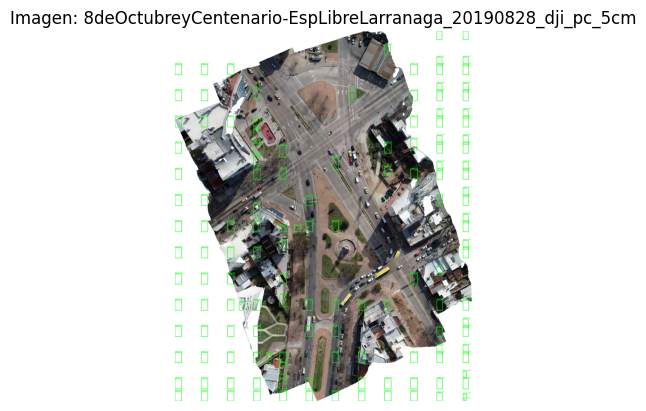

In [ ]:
VisualizadorCocoDataset.show_annotated_image_path(image_file_path, coco_annotations_path, image_name)

Mostramos los puntos:

In [ ]:
predictions.as_pandas()

,x1,y1,x2,y2,confidence,class_id,class_name
0,0.00000,490.083801,97.331512,640.000000,0.513604,0,palmera
1,384.00000,490.083801,481.331512,640.000000,0.513604,0,palmera
2,768.00000,490.083893,865.331360,640.000000,0.513549,0,palmera
3,3072.42244,204.457932,3162.417007,351.063904,0.261218,0,palmera
4,3456.00000,490.083801,3553.331512,640.000000,0.513604,0,palmera
...,...,...,...,...,...,...,...
135,3456.00000,5283.078491,3553.360718,5426.000000,0.512733,0,palmera
136,3840.00000,5307.304413,3918.493401,5426.000000,0.513423,0,palmera
137,4224.00000,5324.130524,4279.978298,5426.000000,0.569133,0,palmera
138,4224.00000,4992.000000,4275.022850,5078.468437,0.262672,0,palmera


#### Generar KML

In [ ]:
jgw_data = ProcesadorAnotacionesMongoDB.load_jgw_file_from_mongodb(image_name=image_name, should_download=True)
pprint(jgw_data)

2025-09-06 00:25:39.520 | SUCCESS  | modulo_apps.labeling.procesador_anotaciones_mongodb:load_jgw_file_from_mongodb:688 - Archivo JGW guardado en downloads\jgw\jgw_data.json.


{'x_origin': 577344.7165226148,
 'x_pixel_size': 0.05,
 'x_rotation': 0.0,
 'y_origin': 6139798.10234485,
 'y_pixel_size': -0.05,
 'y_rotation': 0.0}


In [ ]:
gdf = ProcesadorGeoJSONKML.create_geojson_from_annotations(image_name, coco_annotations, jgw_data, should_download=True)
gdf.head()

2025-09-06 00:25:42.384 | INFO     | modulo_apps.labeling.procesador_geojson_kml:create_geojson_from_annotations:297 - GeoJSON guardado en downloads\geojson\annotations.geojson


,name,annotation_id,confidence,bbox_x,bbox_y,bbox_width,bbox_height,global_tl_x,global_tl_y,global_br_x,global_br_y,geometry
0,palmera,1,0.51,0.00000,490.083801,97.331512,149.916199,577344.716523,6.139774e+06,577349.583098,6.139766e+06,POINT (-56.1536 -34.88151)
1,palmera,2,0.51,384.00000,490.083801,97.331512,149.916199,577363.916523,6.139774e+06,577368.783098,6.139766e+06,POINT (-56.15339 -34.88151)
2,palmera,3,0.51,768.00000,490.083893,97.331360,149.916107,577383.116523,6.139774e+06,577387.983091,6.139766e+06,POINT (-56.15318 -34.88151)
3,palmera,4,0.26,3072.42244,204.457932,89.994568,146.605972,577498.337645,6.139788e+06,577502.837373,6.139781e+06,POINT (-56.15193 -34.88137)
4,palmera,5,0.51,3456.00000,490.083801,97.331512,149.916199,577517.516523,6.139774e+06,577522.383098,6.139766e+06,POINT (-56.15171 -34.8815)


In [ ]:
kml = ProcesadorGeoJSONKML.generate_kml_from_geojson(gdf, should_download=True)

2025-09-06 00:25:42.486 | INFO     | modulo_apps.labeling.procesador_geojson_kml:generate_kml_from_geojson:432 - Archivo KML guardado en downloads\kmls\palmeras.kml


In [ ]:
# Test
kml_text = kml.to_string()
gdf_test = ProcesadorGeoJSONKML.convert_kml_to_geojson(kml_text)

2025-09-06 00:25:42.558 | SUCCESS  | modulo_apps.labeling.procesador_geojson_kml:convert_kml_to_geojson:120 - Conversión exitosa.
